In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
DATA_PATH_10 = Path(r'C:\Users\user00\Desktop\MCI_Diffusion\src\data\daejeon_3000_random_10runs_dataset.csv') # 학습 데이터 (사고규모 10-50, 29890)
DATA_PATH_30 = Path(r'C:\Users\user00\Desktop\MCI_Diffusion\src\data\daejeon_3000_random_30runs_dataset.csv')

OUT_DIR = os.path.join('outputs', 'analysis')
os.makedirs(OUT_DIR, exist_ok=True)

In [18]:
df_10runs = pd.read_csv(DATA_PATH_10)
df_30runs = pd.read_csv(DATA_PATH_30)

In [19]:
# 지역 경계를 그리는 함수
import geopandas as gpd

shp_path = r"C:\Users\user00\Desktop\MCI_Diffusion\MCI_ADV2\scenarios\ctprvn.shp"
gdf = gpd.read_file(shp_path)


def overlay_daejeon_boundary(ax):
    gdf = gpd.read_file(shp_path)
    try:
        gdf_wgs84 = gdf.set_crs(epsg=5179, allow_override=True).to_crs(epsg=4326)
        gdf_daejeon = gdf_wgs84[gdf_wgs84['CTP_ENG_NM'].str.lower() == 'daejeon']
        gdf_daejeon.boundary.plot(ax=ax, color='black', linewidth=1.2, linestyle='--')
    except Exception as e:
        print(f"[WARN] daejeon boundary overlay skipped: {e}")
        

In [20]:
# 보고 싶은 run_idx 지정
RUN_IDX = [0, 7]  # ← 원하는 값으로 바꿔
# 조건 필터링
df_filtered = df_10runs[
    (df_10runs['pdr'] >= 0.5) &
    (df_10runs['run_idx'].isin(RUN_IDX))
].copy()

In [21]:
gdf_points = gpd.GeoDataFrame(
    df_filtered,
    geometry=gpd.points_from_xy(df_filtered['lon'], df_filtered['lat']),
    crs="EPSG:4326"
)

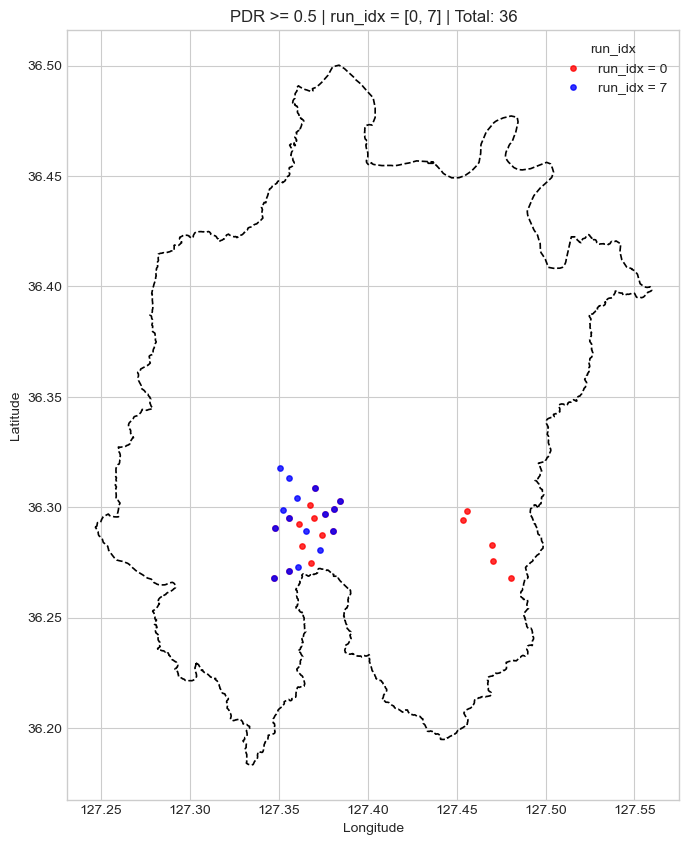

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, run in enumerate(RUN_IDX):
    subset = gdf_points[gdf_points['run_idx'] == run]
    
    subset.plot(
        ax=ax,
        color=colors[i % len(colors)],
        markersize=15,
        alpha=0.8,
        label=f'run_idx = {run}' 
    )

overlay_daejeon_boundary(ax)

# 스타일
ax.set_title(f"PDR >= 0.5 | run_idx = {RUN_IDX} | Total: {len(df_filtered)}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title='run_idx')

plt.show()

[SKIP] run_idx=7


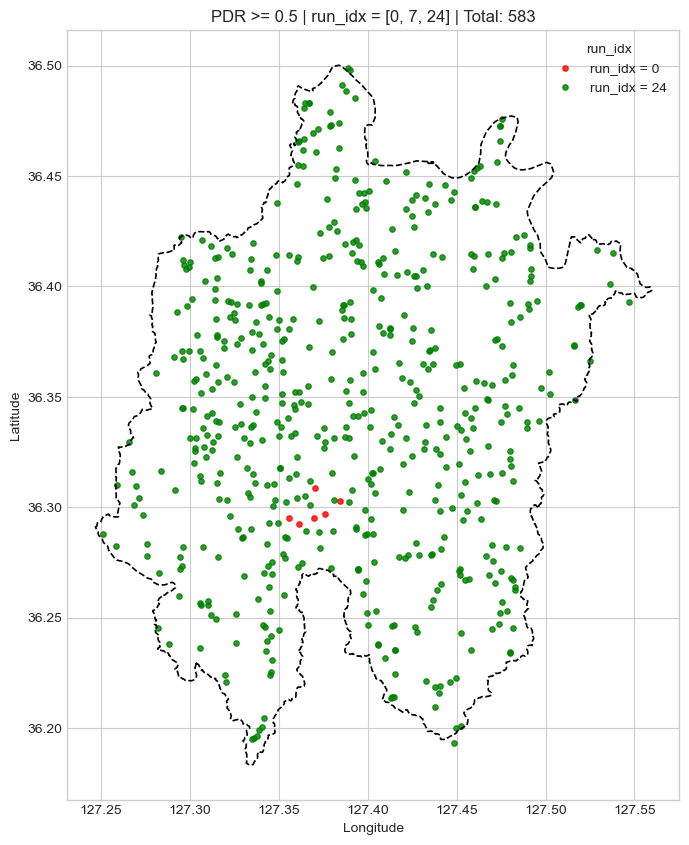

In [32]:
RUN_IDX = [0, 7, 24]  # ← 원하는 값으로 바꿔
# 조건 필터링
df_filtered = df_30runs[
    (df_30runs['pdr'] >= 0.6) &
    (df_30runs['run_idx'].isin(RUN_IDX))
].copy()

gdf_points = gpd.GeoDataFrame(
    df_filtered,
    geometry=gpd.points_from_xy(df_filtered['lon'], df_filtered['lat']),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['red', 'blue', 'green', 'orange', 'purple']

valid_runs = []

for i, run in enumerate(RUN_IDX):
    subset = gdf_points[gdf_points['run_idx'] == run]

    if subset.empty:
        print(f"[SKIP] run_idx={run}")
        continue
    
    valid_runs.append(run)

    subset.plot(
        ax=ax,
        color=colors[i % len(colors)],
        markersize=15,
        alpha=0.8,
        label=f'run_idx = {run}'
    )

if valid_runs:
    ax.legend(title='run_idx')

overlay_daejeon_boundary(ax)

# 스타일
ax.set_title(f"PDR >= 0.5 | run_idx = {RUN_IDX} | Total: {len(df_filtered)}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title='run_idx')

plt.show()